In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
np.random.seed(42)

n = 40

# Class 0
X0 = np.random.randn(n, 2) + np.array([0, 0])

# Class 1
X1 = np.random.randn(n, 2) + np.array([3, 3])

X_easy = np.vstack([X0, X1])
y_easy = np.array([0]*n + [1]*n)

print("X_easy shape:", X_easy.shape)
print("y_easy shape:", y_easy.shape)

X_easy shape: (80, 2)
y_easy shape: (80,)


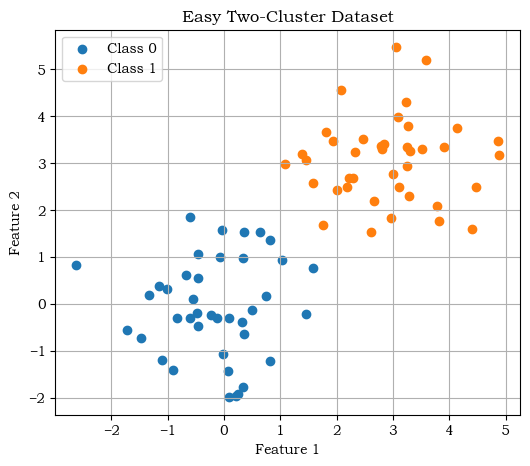

In [4]:
plt.figure(figsize=(6, 5))
plt.scatter(X_easy[y_easy==0][:, 0], X_easy[y_easy==0][:, 1], label="Class 0")
plt.scatter(X_easy[y_easy==1][:, 0], X_easy[y_easy==1][:, 1], label="Class 1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Easy Two-Cluster Dataset")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
tree_easy = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_easy.fit(X_easy, y_easy)
y_pred_tree_easy = tree_easy.predict(X_easy)

acc_tree_easy = accuracy_score(y_easy, y_pred_tree_easy)
print("Single Decision Tree accuracy (easy dataset):", acc_tree_easy)

Single Decision Tree accuracy (easy dataset): 1.0


In [6]:
forest_easy = RandomForestClassifier(
    n_estimators=15,   # 15棵树
    max_depth=3,
    max_features=1,    # 每次分裂只随机看1个特征
    bootstrap=True,    # bootstrap sampling
    random_state=42
)

forest_easy.fit(X_easy, y_easy)
y_pred_forest_easy = forest_easy.predict(X_easy)

acc_forest_easy = accuracy_score(y_easy, y_pred_forest_easy)
print("Random Forest accuracy (easy dataset):", acc_forest_easy)

Random Forest accuracy (easy dataset): 1.0


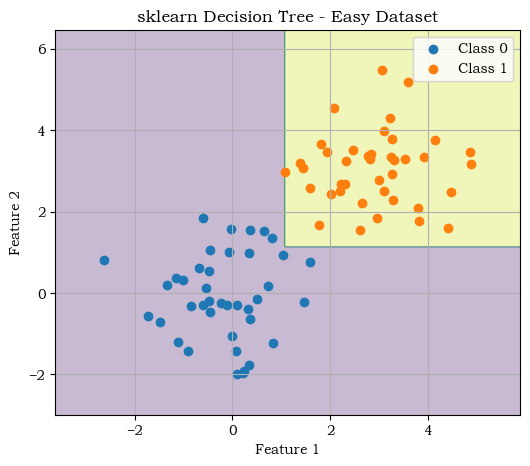

In [7]:
plot_decision_boundary(tree_easy, X_easy, y_easy, title="sklearn Decision Tree - Easy Dataset")

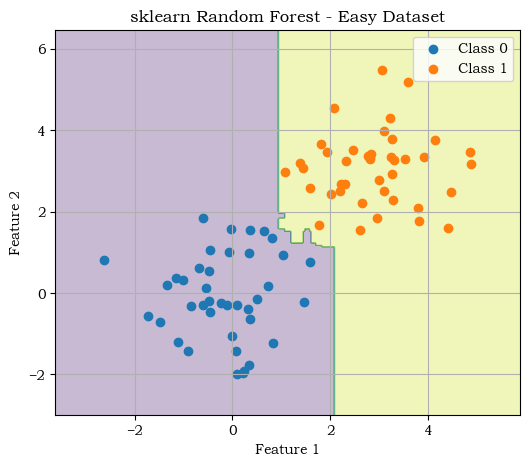

In [8]:
plot_decision_boundary(forest_easy, X_easy, y_easy, title="sklearn Random Forest - Easy Dataset")

In [9]:
print("Easy dataset:")
print("Single Tree accuracy :", acc_tree_easy)
print("Random Forest accuracy:", acc_forest_easy)

Easy dataset:
Single Tree accuracy : 1.0
Random Forest accuracy: 1.0


In [10]:
np.random.seed(123)

n = 50
noise = 0.4

# Class 0: 左下 + 右上
X0_a = np.random.randn(n, 2) * noise + np.array([-1.5, -1.5])
X0_b = np.random.randn(n, 2) * noise + np.array([ 1.5,  1.5])

# Class 1: 左上 + 右下
X1_a = np.random.randn(n, 2) * noise + np.array([-1.5,  1.5])
X1_b = np.random.randn(n, 2) * noise + np.array([ 1.5, -1.5])

X_xor = np.vstack([X0_a, X0_b, X1_a, X1_b])
y_xor = np.array([0]*(2*n) + [1]*(2*n))

print("X_xor shape:", X_xor.shape)
print("y_xor shape:", y_xor.shape)

X_xor shape: (200, 2)
y_xor shape: (200,)


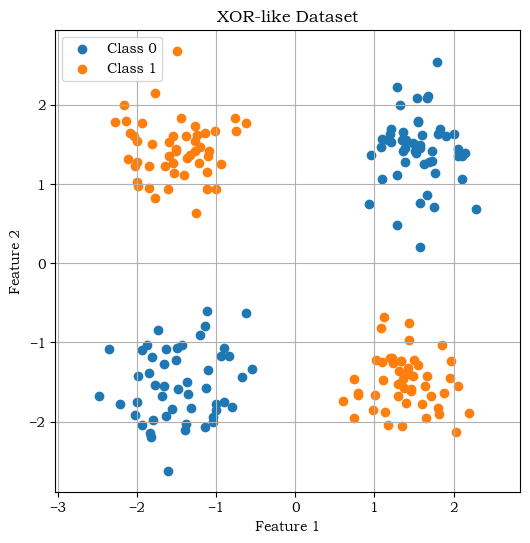

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(X_xor[y_xor==0][:, 0], X_xor[y_xor==0][:, 1], label="Class 0")
plt.scatter(X_xor[y_xor==1][:, 0], X_xor[y_xor==1][:, 1], label="Class 1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("XOR-like Dataset")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

In [12]:
tree_xor = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_xor.fit(X_xor, y_xor)
y_pred_tree_xor = tree_xor.predict(X_xor)

acc_tree_xor = accuracy_score(y_xor, y_pred_tree_xor)
print("Single Decision Tree accuracy (XOR dataset):", acc_tree_xor)

Single Decision Tree accuracy (XOR dataset): 0.985


In [13]:
forest_xor = RandomForestClassifier(
    n_estimators=20,
    max_depth=4,
    max_features=1,
    bootstrap=True,
    random_state=42
)

forest_xor.fit(X_xor, y_xor)
y_pred_forest_xor = forest_xor.predict(X_xor)

acc_forest_xor = accuracy_score(y_xor, y_pred_forest_xor)
print("Random Forest accuracy (XOR dataset):", acc_forest_xor)

Random Forest accuracy (XOR dataset): 1.0


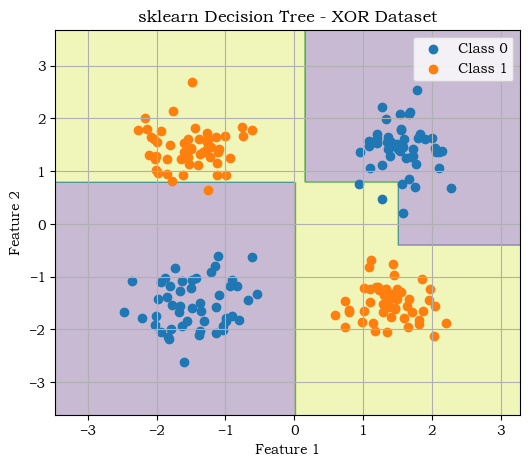

In [14]:
plot_decision_boundary(tree_xor, X_xor, y_xor, title="sklearn Decision Tree - XOR Dataset")

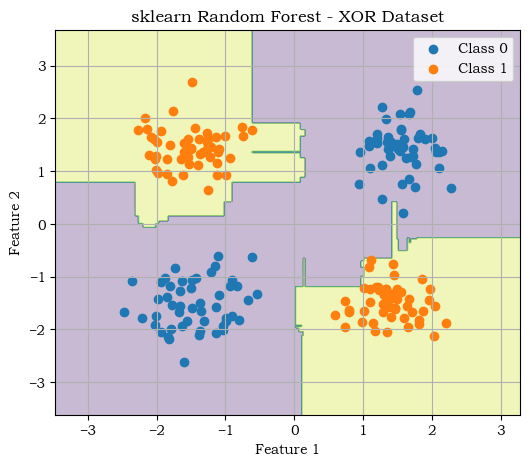

In [15]:
plot_decision_boundary(forest_xor, X_xor, y_xor, title="sklearn Random Forest - XOR Dataset")

In [16]:
print("XOR dataset:")
print("Single Tree accuracy :", acc_tree_xor)
print("Random Forest accuracy:", acc_forest_xor)

XOR dataset:
Single Tree accuracy : 0.985
Random Forest accuracy: 1.0
